global phase: π/2
     ┌─────────┐┌────┐┌─────────┐      ░ ┌───────┐┌────┐┌────────┐┌────┐»
q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■───░─┤ Rz(π) ├┤ √X ├┤ Rz(2π) ├┤ √X ├»
     └─────────┘└────┘└─────────┘┌─┴─┐ ░ └───────┘└────┘└────────┘└────┘»
q_1: ────────────────────────────┤ X ├─░────────────────────────────────»
                                 └───┘ ░                                »
c: 2/═══════════════════════════════════════════════════════════════════»
                                                                        »
«     ┌────────┐ ░ ┌───┐ ░      ┌─────────┐┌────┐┌─────────┐ ░ ┌─┐   
«q_0: ┤ Rz(3π) ├─░─┤ I ├─░───■──┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─░─┤M├───
«     └────────┘ ░ └───┘ ░ ┌─┴─┐└─────────┘└────┘└─────────┘ ░ └╥┘┌─┐
«q_1: ───────────░───────░─┤ X ├─────────────────────────────░──╫─┤M├
«                ░       ░ └───┘                             ░  ║ └╥┘
«c: 2/══════════════════════════════════════════════════════════╩══╩═
«                                           

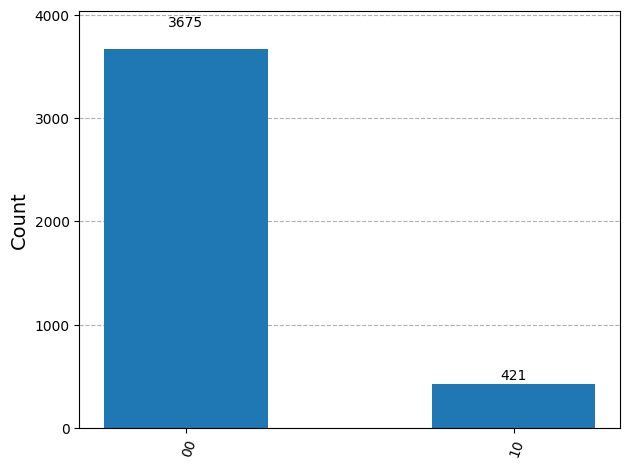

In [ ]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise import pauli_error

# ============================================================
# PARAMETERS
# ============================================================

shots = 4096

# Bit-flip probability
p = 0.9

# Alice's encoding operator
# I, X, Y, Z
message = "X"

# ============================================================
# CREATE CIRCUIT
# ============================================================

qc = QuantumCircuit(2,2)

# ============================================================
# BELL STATE PREPARATION
# ============================================================

qc.h(0)
qc.cx(0,1)

qc.barrier()

# ============================================================
# ALICE ENCODING
# ============================================================

if message == "X":
    qc.x(0)

elif message == "Y":
    qc.y(0)

elif message == "Z":
    qc.z(0)


qc.barrier()

qc.id(0)

qc.barrier()

# ============================================================
# BOB DECODER
#
# Inverse Bell preparation
# ============================================================

qc.cx(0,1)
qc.h(0)

qc.barrier()

qc.measure([0,1],[0,1])

# ============================================================
# BIT-FLIP NOISE MODEL
# ============================================================

bit_flip = pauli_error([
    ('X', p),
    ('I', 1-p)
])

noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(
    bit_flip,
    ['id']
)


backend = AerSimulator(noise_model=noise_model)

tqc = transpile(
    qc,
    backend,
    optimization_level=0
)

print(tqc)

result = backend.run(
    tqc,
    shots=shots
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

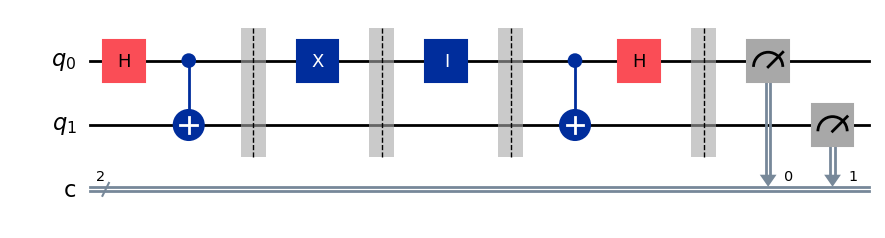

In [2]:
qc.draw(output="mpl")

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ranga\AppData\Local\Temp\ipykernel_17504\3481868419.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Noise parameter $\eta_B$', fontsize=12)


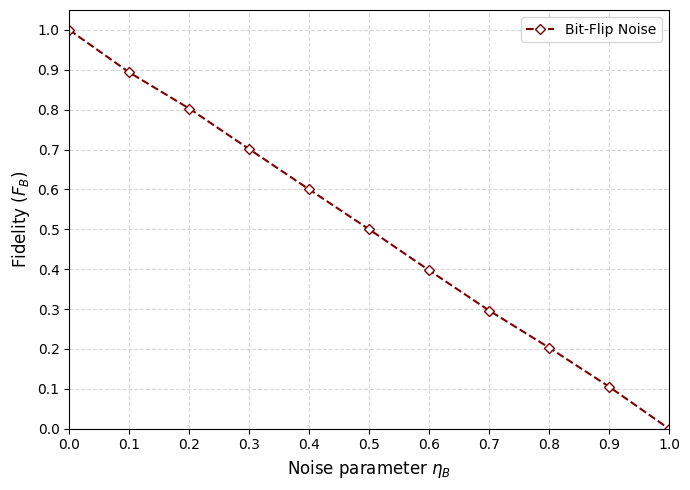

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Data
# ================================

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4,
              0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

y = np.array([1.0,
              0.89355,
              0.80297,
              0.701171,
              0.600097,
              0.5,
              0.397216,
              0.29638,
              0.20336,
              0.10546,
              0.0])


plt.figure(figsize=(7,5))

plt.plot(
    x,
    y,
    color='maroon',
    linestyle='--',
    marker='D',
    markersize=5,
    markerfacecolor='white',
    linewidth=1.5,
    label='Bit-Flip Noise'
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xticks(np.arange(0,1.1,0.1))
plt.yticks(np.arange(0,1.1,0.1))

plt.xlabel('Noise parameter $\eta_B$', fontsize=12)
plt.ylabel('Fidelity ($F_B$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()